In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as cx
import folium
from folium.plugins import HeatMap

# Load dataset

In [2]:
dataset_path = "./dataset1/merged_dataset.csv"
df = pd.read_csv(dataset_path)
df.head()

,Origin Time,Latitude[degree],Longitude[degree],Depth[km],Magnitude,Max Acc[gal],Max Vel[cm/s],Seismic Intensity,Number of stations
0,2000/01/09 13:02:00,37.273,141.703,46,5.0,47.1,1.2,2.9,83
1,2000/01/15 16:29:00,37.818,142.622,34,4.6,7.6,0.3,1.6,9
2,2000/01/23 16:40:00,30.262,131.023,22,5.2,97.7,5.9,3.8,21
3,2000/01/24 21:50:00,37.128,141.567,46,4.5,36.9,1.0,2.3,43
4,2000/01/25 18:02:00,43.455,145.830,71,4.7,51.6,1.2,2.7,23


# Dataset details
01/01/2000 to 15/05/2026

Number of earthquakes: 4361

Columns in the dataset: ['Origin Time', 'Latitude[degree]', 'Longitude[degree]', 'Depth[km]', 'Magnitude', 'Max Acc[gal]', 'Max Vel[cm/s]', 'Seismic Intensity', 'Number of stations']

Magnitude statistics:
count    4361.000000
mean        5.088489
std         0.595361
min         4.500000
25%         4.600000
50%         4.900000
75%         5.400000
max         9.000000
Name: Magnitude, dtype: float64


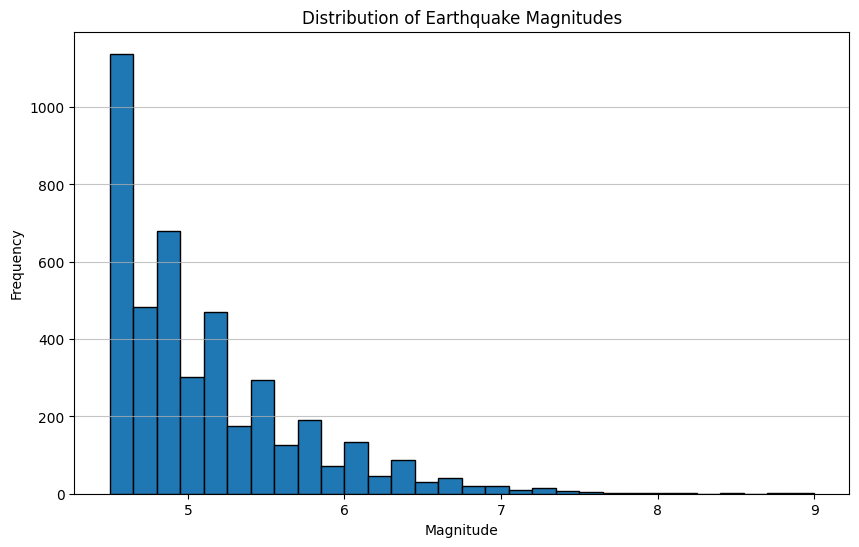

In [3]:
print("Number of earthquakes:", len(df))
print("\nColumns in the dataset:", df.columns.tolist())
print("\nMagnitude statistics:")
print(df['Magnitude'].describe())
plt.figure(figsize=(10, 6))
plt.hist(df['Magnitude'], bins=30, edgecolor='black')
plt.title('Distribution of Earthquake Magnitudes')
plt.xlabel('Magnitude')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Eartquake location map

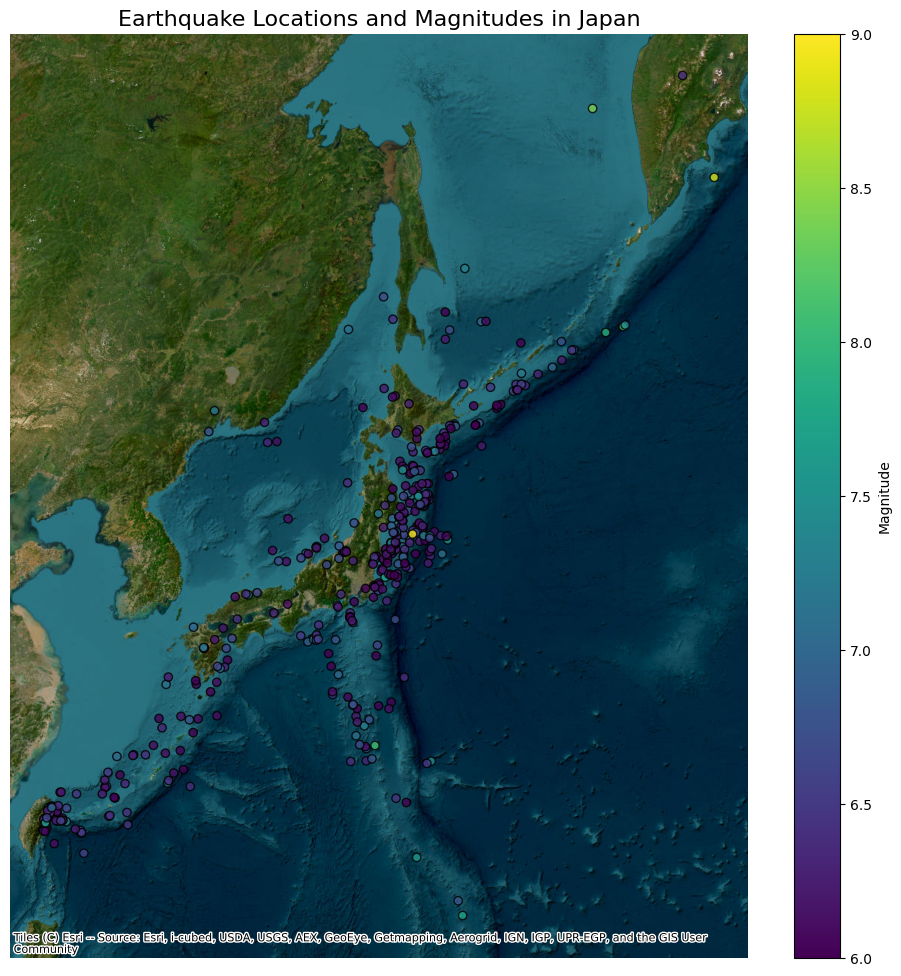

In [4]:
# 1. Convert your standard pandas DataFrame into a GeoDataFrame
# We tell it which columns are the coordinates, and set the standard GPS CRS (EPSG:4326)
df6 = df[df['Magnitude'] >= 6.0]
gdf = gpd.GeoDataFrame(
    df6, 
    geometry=gpd.points_from_xy(df6['Longitude[degree]'], df6['Latitude[degree]']),
    crs="EPSG:4326"
)

# 2. Convert the coordinates to Web Mercator (EPSG:3857) so they align with web map tiles
gdf = gdf.to_crs(epsg=3857)

# 3. Create the plot
fig, ax = plt.subplots(figsize=(12, 12))

# 4. Plot the earthquakes directly from the GeoDataFrame
scatter = gdf.plot(
    ax=ax,
    column='Magnitude',
    cmap='viridis',
    alpha=0.8,
    edgecolor='k',
    legend=True,
    legend_kwds={'label': 'Magnitude'}
)

# 5. Add the realistic basemap! 
# Using Esri World Imagery for a realistic satellite view. 
# You can change this to cx.providers.OpenStreetMap.Mapnik for a standard map.
cx.add_basemap(ax, source=cx.providers.Esri.WorldImagery)

# 6. Clean up the plot (hiding axis numbers since they are in Web Mercator meters now)
ax.set_axis_off()
plt.title('Earthquake Locations and Magnitudes in Japan', fontsize=16)
plt.show()

In [5]:
#with all eathquake
# 1. Find the center of our map based on the dataset
center_lat = df['Latitude[degree]'].mean()
center_lon = df['Longitude[degree]'].mean()

# 2. Create the interactive base map
# 'OpenStreetMap' is the default, but 'cartodbpositron' looks very clean for data overlays.
m = folium.Map(
    location=[center_lat, center_lon], 
    zoom_start=5, 
    tiles='cartodbpositron'
)

# 3. Create a helper function to color-code the earthquakes by magnitude
def get_color(magnitude):
    if magnitude >= 7.0:
        return 'darkred'
    elif magnitude >= 6.0:
        return 'red'
    elif magnitude >= 5.0:
        return 'orange'
    else:
        return 'green'

# 4. Add the earthquakes as interactive circle markers
for idx, row in df.iterrows():
    folium.CircleMarker(
        location=[row['Latitude[degree]'], row['Longitude[degree]']],
        # Scale the size of the circle based on magnitude
        radius=row['Magnitude'] ** 1.2, 
        # Create an interactive popup that shows when you click the point
        popup=f"<b>Magnitude:</b> {row['Magnitude']}<br>"
              f"<b>Depth:</b> {row['Depth[km]']} km<br>"
              f"<b>Date:</b> {row['Origin Time']}",
        color=get_color(row['Magnitude']),
        fill=True,
        fill_color=get_color(row['Magnitude']),
        fill_opacity=0.6,
        weight=0.5
    ).add_to(m)

# 5. Display the interactive map in the n
print("Number of earthquakes with magnitude >= 4.5:", len(df))
m

Number of earthquakes with magnitude >= 4.5: 4361


In [6]:
#with only magnitude 6+ eathquake
# 1. Find the center of our map based on the dataset
center_lat = df6['Latitude[degree]'].mean()
center_lon = df6['Longitude[degree]'].mean()

# 2. Create the interactive base map
# 'OpenStreetMap' is the default, but 'cartodbpositron' looks very clean for data overlays.
m = folium.Map(
    location=[center_lat, center_lon], 
    zoom_start=5, 
    tiles='cartodbpositron'
)

# 3. Create a helper function to color-code the earthquakes by magnitude
def get_color(magnitude):
    if magnitude >= 8.0:
        return 'darkred'
    elif magnitude >= 7.0:
        return 'red'
    elif magnitude >= 6.5:
        return 'orange'
    else:
        return 'yellow'

# 4. Add the earthquakes as interactive circle markers
for idx, row in df6.iterrows():
    folium.CircleMarker(
        location=[row['Latitude[degree]'], row['Longitude[degree]']],
        # Scale the size of the circle based on magnitude
        radius=row['Magnitude'] ** 1.2, 
        # Create an interactive popup that shows when you click the point
        popup=f"<b>Magnitude:</b> {row['Magnitude']}<br>"
              f"<b>Depth:</b> {row['Depth[km]']} km<br>"
              f"<b>Date:</b> {row['Origin Time']}",
        color=get_color(row['Magnitude']),
        fill=True,
        fill_color=get_color(row['Magnitude']),
        fill_opacity=0.6,
        weight=0.5
    ).add_to(m)

# 5. Display the interactive map in the n
print("Number of earthquakes with magnitude >= 6.0:", len(df6))
m

Number of earthquakes with magnitude >= 6.0: 425


# earthquake heat map

In [17]:
# 1. Create a new base map centered around the average coordinates
heat_map = folium.Map(
    location=[df['Latitude[degree]'].mean(), df['Longitude[degree]'].mean()], 
    zoom_start=2
)

# 2. Extract the Latitude and Longitude columns as a list of lists
# Using .dropna() ensures we don't get errors from missing coordinates
heat_data = df[['Latitude[degree]', 'Longitude[degree]']].dropna().values.tolist()

# NOTE: If you want the heat map to be weighted by the earthquake's Magnitude, 
# you can include the magnitude column like this instead:
heat_data = df[['Latitude[degree]', 'Longitude[degree]', 'Magnitude']].dropna().values.tolist()

# 3. Add the HeatMap layer to your map
HeatMap(heat_data, radius=12, blur=15, max_zoom=1).add_to(heat_map)

# 4. Display the map
heat_map

# One earthquake detail

In [8]:
#display detail about the earthquake with the highest magnitude
fukushima = df6[df6['Magnitude'] == df6['Magnitude'].max()]
print(fukushima[['Origin Time', 'Latitude[degree]', 'Longitude[degree]', 'Depth[km]', 'Magnitude']])
#show on map
fukushima_map = folium.Map(location=[fukushima['Latitude[degree]'].iloc[0], fukushima['Longitude[degree]'].iloc[0]], zoom_start=10)
folium.Marker(
    location=[fukushima['Latitude[degree]'].iloc[0], fukushima['Longitude[degree]'].iloc[0]],
    popup=f"<b>Magnitude:</b> {fukushima['Magnitude'].iloc[0]}<br>"
          f"<b>Depth:</b> {fukushima['Depth[km]'].iloc[0]} km<br>"
          f"<b>Date:</b> {fukushima['Origin Time'].iloc[0]}",
    icon=folium.Icon(color='red', icon='info-sign')
).add_to(fukushima_map)
fukushima_map


              Origin Time  Latitude[degree]  Longitude[degree]  Depth[km]  \
1550  2011/03/11 14:46:00              38.1            142.864         24   

      Magnitude  
1550        9.0  
